In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

df_raw = pd.read_csv("healthcare-dataset-stroke-data.csv")
df_work = df_raw.copy() #資料處理後的資料集


檢查資料

In [2]:
print("資料大小：")
print(df_work.shape)

print("\n前五筆資料：")
print(df_work.head())

print("\n欄位資訊：")
print(df_work.info())

print("\n統計資料：")
print(df_work.describe())

資料大小：
(5110, 12)

前五筆資料：
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

欄位資訊：
<class 'pandas.DataFrame

## 視覺化
透過圖表了解資料級患有中風與非中風的比例

C:\Users\wang\AppData\Local\Temp\ipykernel_30080\4089430762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


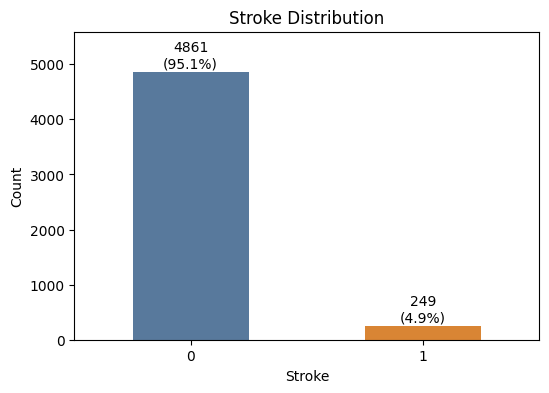

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x='stroke',
    data=df_work,
    palette=['#4C78A8', '#F58518'],
    width=0.5
)

plt.title("Stroke Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")

total = len(df_work)

for p in ax.patches:
    height = p.get_height()
    percentage = height / total * 100
    
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 20,
        f"{int(height)}\n({percentage:.1f}%)",
        ha='center',
        va='bottom'
    )

plt.ylim(0, df_work['stroke'].value_counts().max() * 1.15)

plt.show()

年齡與中風關係

C:\Users\wang\AppData\Local\Temp\ipykernel_30080\1979129149.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y='age', data=df_work,palette=['#4C78A8', '#F58518'],


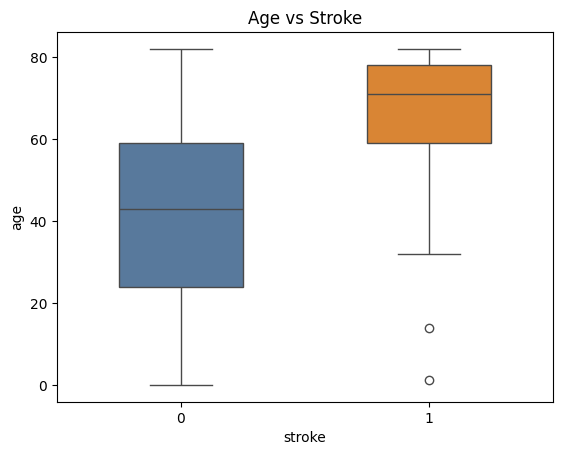

In [4]:
sns.boxplot(x='stroke', y='age', data=df_work,palette=['#4C78A8', '#F58518'],     
    width=0.5)
plt.title("Age vs Stroke")
plt.show()

In [5]:
print(df_work.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [6]:
df_work['bmi'] = df_work['bmi'].fillna(df_work['bmi'].mean())
print(df_work.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


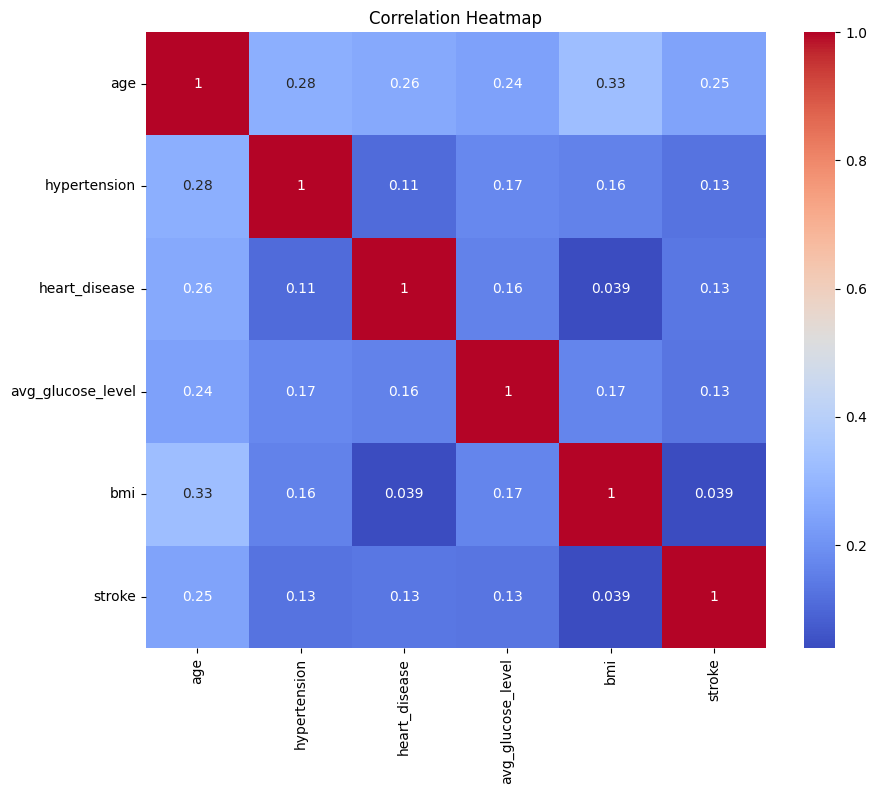

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df_work.drop(columns=['id'], errors='ignore').corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


One-hot encoding

In [8]:
print("轉換前的欄位及欄位數量：", len(df_raw.columns))
print(df_raw.columns)

df_work = pd.get_dummies(df_work, drop_first=True)

print("\n轉換後的欄位及欄位數量：", len(df_work.columns))
print(df_work.columns)

print("\n轉換後缺失值檢查：")
print(df_work.isnull().sum())

轉換前的欄位及欄位數量： 12
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

轉換後的欄位及欄位數量： 18
Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke', 'gender_Male', 'gender_Other', 'ever_married_Yes',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='str')

轉換後缺失值檢查：
id                                0
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Male                       0
gender_Other                      0
ever_married_Yes         

標準化（Normalization）

In [9]:
from sklearn.preprocessing import MinMaxScaler

X = df_work.drop(['stroke', 'id'], axis=1)
y = df_work['stroke']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df[['age','bmi','avg_glucose_level']].describe()
print("Normalization 後統計：")
print(X_scaled_df[['age','bmi','avg_glucose_level']].describe())

Normalization 後統計：
               age          bmi  avg_glucose_level
count  5110.000000  5110.000000        5110.000000
mean      0.526692     0.212981           0.235563
std       0.276033     0.088179           0.209046
min       0.000000     0.000000           0.000000
25%       0.304199     0.154639           0.102137
50%       0.548340     0.207331           0.169721
75%       0.743652     0.257732           0.272228
max       1.000000     1.000000           1.000000


In [10]:
print(X_scaled_df.columns)

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'gender_Male', 'gender_Other', 'ever_married_Yes',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='str')


## ML

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,  #20%的數據分配給測試集
    random_state=42,    #分層抽樣
    stratify=y  #分層抽樣
)

print("訓練集大小：", X_train.shape)
print("測試集大小：", X_test.shape)
print(y_train.value_counts(normalize=True))

訓練集大小： (4088, 16)
測試集大小： (1022, 16)
stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64


## LR

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix：")
print(cm)

Confusion Matrix：
[[972   0]
 [ 49   1]]


模型為了提高準確率，乾脆全部猜 0
雖然模型整體準確率較高，但從混淆矩陣可觀察到模型完全未能識別任何中風病例（Recall = 0）。這是由於資料嚴重不平衡，導致模型傾向預測多數類別，造成醫療上不可接受的錯誤，因此這是一個失敗的模型。

In [13]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix：")
print(cm)

Confusion Matrix：
[[721 251]
 [ 10  40]]


# RF

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight={0:1, 1:5},  # 強化中風權重
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_rf))

[[972   0]
 [ 50   0]]


## KNN

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

from sklearn.metrics import confusion_matrix
print("KNN Confusion Matrix：")
print(confusion_matrix(y_test, y_pred_knn))

KNN Confusion Matrix：
[[970   2]
 [ 48   2]]


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
#Logistic Regression
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
#Random Forest
print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
#KNN
print("KNN")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Logistic Regression
[[721 251]
 [ 10  40]]
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022

Random Forest
[[972   0]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

KNN
[[970   2]
 [ 48   2]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.50      0.04      0.07        50

    accuracy                           0.95      1022
   macro avg       0.

c:\Users\wang\Desktop\資料探勘\期中\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\wang\Desktop\資料探勘\期中\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\wang\Desktop\資料探勘\期中\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

## SMOTE

In [17]:
print("SMOTE 前訓練集類別數量：")
print(y_train.value_counts())

SMOTE 前訓練集類別數量：
stroke
0    3889
1     199
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import SMOTE #SMOTE 只做在訓練集，不做在測試集

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE 後訓練集類別數量：")
print(y_train_smote.value_counts())

SMOTE 後訓練集類別數量：
stroke
0    3889
1    3889
Name: count, dtype: int64


## LR

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

lr_smote = LogisticRegression(max_iter=1000)

lr_smote.fit(X_train_smote, y_train_smote)

y_pred_lr_smote = lr_smote.predict(X_test)

print("Logistic Regression + SMOTE")
print(confusion_matrix(y_test, y_pred_lr_smote))
print(classification_report(y_test, y_pred_lr_smote))

Logistic Regression + SMOTE
[[727 245]
 [ 10  40]]
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.95      0.75      0.82      1022



## RF

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

print("Random Forest + SMOTE")
print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))

Random Forest + SMOTE
[[910  62]
 [ 36  14]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.18      0.28      0.22        50

    accuracy                           0.90      1022
   macro avg       0.57      0.61      0.59      1022
weighted avg       0.92      0.90      0.91      1022



## KNN

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn_smote = KNeighborsClassifier(n_neighbors=5)

knn_smote.fit(X_train_smote, y_train_smote)

y_pred_knn_smote = knn_smote.predict(X_test)

print("KNN + SMOTE")
print(confusion_matrix(y_test, y_pred_knn_smote))
print(classification_report(y_test, y_pred_knn_smote))

KNN + SMOTE
[[812 160]
 [ 32  18]]
              precision    recall  f1-score   support

           0       0.96      0.84      0.89       972
           1       0.10      0.36      0.16        50

    accuracy                           0.81      1022
   macro avg       0.53      0.60      0.53      1022
weighted avg       0.92      0.81      0.86      1022



從 Recall 比較圖可以看出，未處理資料不平衡時，多數模型幾乎無法辨識中風類別。加入 class_weight 或 SMOTE 後，模型對中風病例的辨識能力明顯提升。其中 Logistic Regression + Balanced 的 Recall 最高，達到 0.80，因此最適合作為本研究的主要模型。

In [22]:
# 1. Logistic Regression 原始版
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. Logistic Regression + Balanced
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train, y_train)
y_pred_lr_balanced = lr_balanced.predict(X_test)

# 3. Logistic Regression + SMOTE
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test)

# 4. Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight={0: 1, 1: 5},
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 5. Random Forest + SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)

# 6. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# 7. KNN + SMOTE
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test)

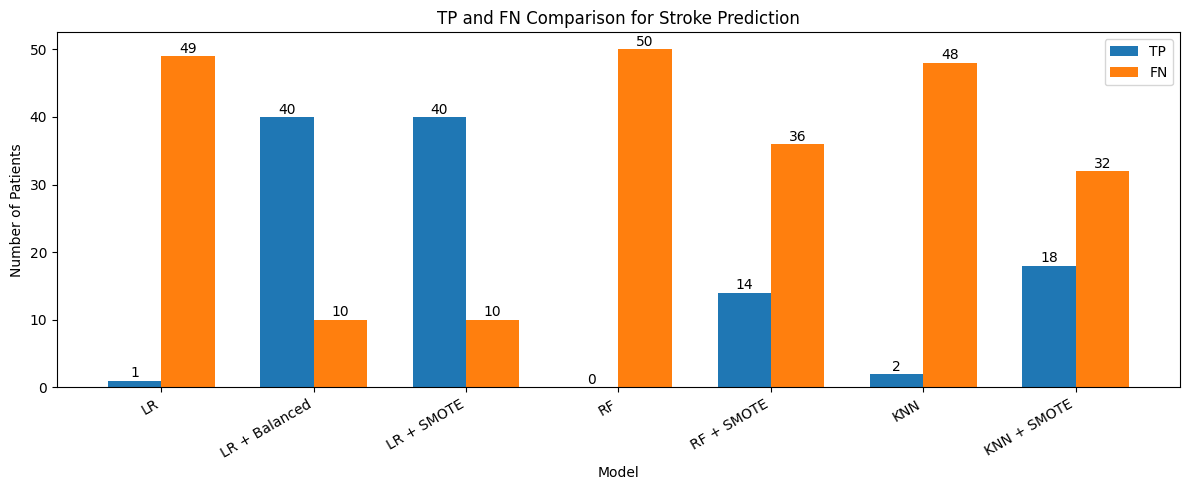

In [23]:
predictions = {
    "LR": y_pred_lr,
    "LR + Balanced": y_pred_lr_balanced,
    "LR + SMOTE": y_pred_lr_smote,
    "RF": y_pred_rf,
    "RF + SMOTE": y_pred_rf_smote,
    "KNN": y_pred_knn,
    "KNN + SMOTE": y_pred_knn_smote
}

models = list(predictions.keys())

tp = []
fn = []

for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)
    tp.append(cm[1, 1])
    fn.append(cm[1, 0])

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, tp, width, label="TP")
plt.bar(x + width/2, fn, width, label="FN")

plt.title("TP and FN Comparison for Stroke Prediction")
plt.xlabel("Model")
plt.ylabel("Number of Patients")
plt.xticks(x, models, rotation=30, ha="right")
plt.legend()

for i in range(len(models)):
    plt.text(x[i] - width/2, tp[i] + 0.5, str(tp[i]), ha="center")
    plt.text(x[i] + width/2, fn[i] + 0.5, str(fn[i]), ha="center")

plt.tight_layout()
plt.show()

FN 代表真正中風但被模型判斷為未中風，是醫療預測中最嚴重的錯誤。從圖中可看出，LR、RF 原始模型皆漏掉全部 50 位中風患者，而 KNN 原始模型也漏掉 47 位。經過資料不平衡處理後，LR + Balanced 的 FN 降至 10，是所有模型中漏診最少的方法。

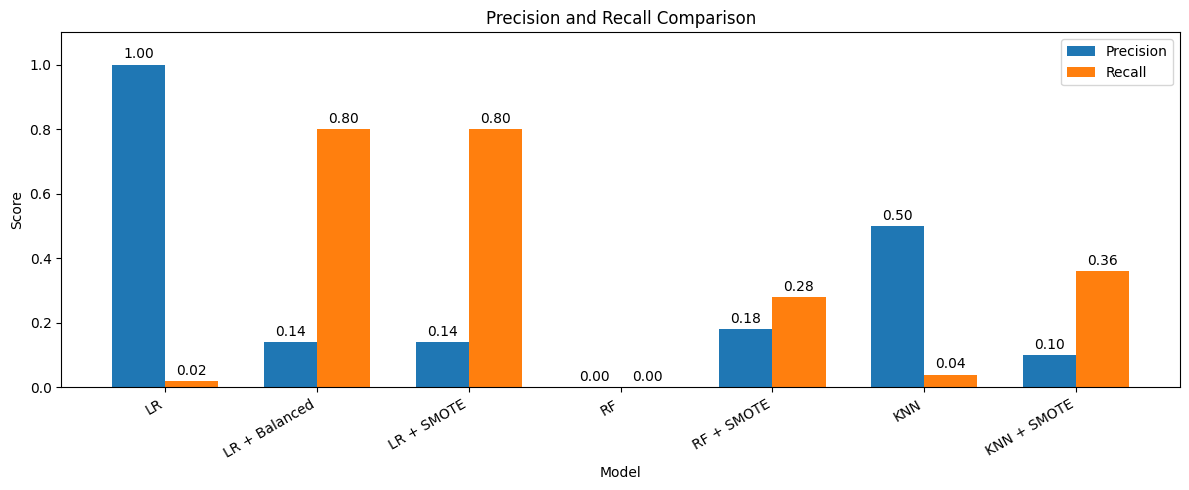

In [24]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    "LR",
    "LR + Balanced",
    "LR + SMOTE",
    "RF",
    "RF + SMOTE",
    "KNN",
    "KNN + SMOTE"
]

precision = [
    1.00,  # LR 原始版
    0.14,  # LR + Balanced
    0.14,  # LR + SMOTE
    0.00,  # RF 原始版
    0.18,  # RF + SMOTE
    0.50,  # KNN 原始版
    0.10   # KNN + SMOTE
]

recall = [
    0.02,  # LR 原始版
    0.80,  # LR + Balanced
    0.80,  # LR + SMOTE
    0.00,  # RF 原始版
    0.28,  # RF + SMOTE
    0.04,  # KNN 原始版
    0.36   # KNN + SMOTE
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, precision, width, label="Precision")
plt.bar(x + width/2, recall, width, label="Recall")

plt.title("Precision and Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(x, models, rotation=30, ha="right")
plt.ylim(0, 1.1)
plt.legend()

for i in range(len(models)):
    plt.text(x[i] - width/2, precision[i] + 0.02, f"{precision[i]:.2f}", ha="center")
    plt.text(x[i] + width/2, recall[i] + 0.02, f"{recall[i]:.2f}", ha="center")

plt.tight_layout()
plt.show()

Precision = 在「模型判斷為中風」的人裡面，有多少是真的中風。

Recall 越高，代表漏診越少。